<a href="https://colab.research.google.com/github/evanz1223/Car-Price-Idetification-Through-Linear-Regression/blob/main/automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error



In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
automobile = fetch_ucirepo(id=10)

# data (as pandas dataframes)
X = automobile.data.features
# Set y to 'price' and then remove 'price' from X
y = X['price']
X = X.drop('price', axis=1)

# metadata
print(automobile.metadata)

# variable information
print(automobile.variables)

{'uci_id': 10, 'name': 'Automobile', 'repository_url': 'https://archive.ics.uci.edu/dataset/10/automobile', 'data_url': 'https://archive.ics.uci.edu/static/public/10/data.csv', 'abstract': "From 1985 Ward's Automotive Yearbook", 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 205, 'num_features': 25, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['symboling'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1985, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5B01C', 'creators': ['Jeffrey Schlimmer'], 'intro_paper': None, 'additional_info': {'summary': 'This data set consists of three types of entities: (a) the specification of an auto in terms of various characteristics, (b) its assigned insurance risk rating, (c) its normalized losses in use as compared to other cars.  The second rating corresponds to the degree to which th

In [4]:
X.head()

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,num-of-cylinders,...,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,6,...,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,4,...,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,5,...,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0


In [5]:
from sklearn.model_selection import train_test_split


missing_percentages = X.isnull().sum() / len(X) * 100



columns_to_drop = missing_percentages[missing_percentages > 30].index.tolist()
X_processed = X.drop(columns=columns_to_drop)

for col in X_processed.select_dtypes(include=np.number).columns:
    if X_processed[col].isnull().any():
        X_processed[col] = pd.to_numeric(X_processed[col], errors='coerce')
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())

X_processed = pd.get_dummies(X_processed, drop_first=True)


combined_data = pd.concat([X_processed, y.rename('target_price')], axis=1)
combined_data.dropna(subset=['target_price'], inplace=True)

X_processed = combined_data.drop('target_price', axis=1)
y = combined_data['target_price']


X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Testing target shape: {y_test.shape}')

Training features shape: (160, 59)
Testing features shape: (41, 59)
Training target shape: (160,)
Testing target shape: (41,)


In [6]:
for col in ['horsepower', 'curb-weight', 'engine-size']:
    if col in X_processed.columns:
        X_processed[col] = pd.to_numeric(X_processed[col], errors='coerce')


for col in ['horsepower', 'curb-weight', 'engine-size']:
    if col in X_processed.columns and X_processed[col].isnull().any():
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())

if 'horsepower' in X_processed.columns and 'curb-weight' in X_processed.columns:
    X_processed['horsepower_to_weight_ratio'] = X_processed['horsepower'] / X_processed['curb-weight']

if 'engine-size' in X_processed.columns:
    X_processed['engine_size_sq'] = X_processed['engine-size'] ** 2

if 'horsepower' in X_processed.columns:
    X_processed['horsepower_sq'] = X_processed['horsepower'] ** 2

print(f"New features added. X_processed shape: {X_processed.shape}")

New features added. X_processed shape: (201, 62)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


X_train_keras, X_test_keras, y_train_keras, y_test_keras = train_test_split(X_processed, y, test_size=0.2, random_state=42)

scaler_keras = StandardScaler()
X_train_scaled_keras = scaler_keras.fit_transform(X_train_keras)
X_test_scaled_keras = scaler_keras.transform(X_test_keras)


y_scaler_keras = StandardScaler()
y_train_scaled_keras = y_scaler_keras.fit_transform(y_train_keras.to_frame()).flatten()
y_test_scaled_keras = y_scaler_keras.transform(y_test_keras.to_frame()).flatten()

assert not np.isnan(X_train_scaled_keras).any(), "NaNs found in X_train_scaled_keras. Check preprocessing."
assert not np.isnan(y_train_scaled_keras).any(), "NaNs found in y_train_scaled_keras. Check preprocessing."

print(f'Training features shape (after feature engineering): {X_train_scaled_keras.shape}')
print(f'Testing features shape (after feature engineering): {X_test_scaled_keras.shape}')

Training features shape (after feature engineering): (160, 62)
Testing features shape (after feature engineering): (41, 62)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
model_fe = Sequential([
    Input(shape=(X_train_scaled_keras.shape[1],)),
    Dense(128, activation='leaky_relu'),
    Dense(64, activation='leaky_relu'),
    Dense(32, activation='leaky_relu'),
    Dense(1)
])


opt_fe = Adam(learning_rate=0.001)
model_fe.compile(
    optimizer=opt_fe,
    loss='mean_squared_error',
    metrics=['mae']
)


early_stop_fe = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_fe = model_fe.fit(
    X_train_scaled_keras, y_train_scaled_keras,
    epochs=1000,
    batch_size=32,
    validation_data=(X_test_scaled_keras, y_test_scaled_keras),
    callbacks=[early_stop_fe],
    shuffle=True
)


Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.8496 - mae: 0.6533 - val_loss: 0.9567 - val_mae: 0.6467
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2516 - mae: 0.3840 - val_loss: 0.6160 - val_mae: 0.5541
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1276 - mae: 0.2865 - val_loss: 0.4180 - val_mae: 0.3761
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0717 - mae: 0.2063 - val_loss: 0.3206 - val_mae: 0.3383
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0607 - mae: 0.1968 - val_loss: 0.2753 - val_mae: 0.3243
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0427 - mae: 0.1645 - val_loss: 0.2514 - val_mae: 0.3020
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0337 - mae: 0.1376 - val_loss: 0.2272 - val_mae: 0.2883
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0314 - mae: 0.1325 - val_loss: 0.2228 - val_mae: 0.2912
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.02

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_scaled_fe_keras = model_fe.predict(X_test_scaled_keras)

y_pred_fe_keras = y_scaler_keras.inverse_transform(y_pred_scaled_fe_keras).flatten()
y_test_original_fe = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()


mse_fe_keras = mean_squared_error(y_test_original_fe, y_pred_fe_keras)
mae_fe_keras = mean_absolute_error(y_test_original_fe, y_pred_fe_keras)

print(f'Keras Model (with Feature Engineering) - Test MSE (original scale): {mse_fe_keras:.2f}')
print(f'Keras Model (with Feature Engineering) - Test MAE (original scale): {mae_fe_keras:.2f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Keras Model (with Feature Engineering) - Test MSE (original scale): 8122431.41
Keras Model (with Feature Engineering) - Test MAE (original scale): 1837.88


In [ ]:
!pip install -q keras-tuner
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense

class RegressionHyperModel(kt.HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(self.input_shape,)))


        model.add(keras.layers.Dense(
            units=hp.Int('units_1', min_value=64, max_value=1024, step=32),
            activation='leaky_relu'
        ))

        model.add(keras.layers.Dense(
            units=hp.Int('units_2', min_value=32, max_value=64, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the third Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_3', min_value=16, max_value=32, step=16),
            activation='leaky_relu'
        ))
        model.add(keras.layers.Dense(1)) # Output layer for regression

        # Tune the learning rate for the Adam optimizer
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        model.compile(
            optimizer=optimizer,
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

# Instantiate the HyperModel with the (possibly new) input shape from feature engineering
hypermodel = RegressionHyperModel(input_shape=X_train_scaled_keras.shape[1])

# Set up the tuner (e.g., RandomSearch or Hyperband)
tuner = kt.RandomSearch(
    hypermodel,
    objective='val_mae', # Minimize validation MAE
    max_trials=100,       # Number of hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each combination (for robustness)
    directory='keras_tuner_dir',
    project_name='car_price_prediction_revisited',
    overwrite=True # Overwrite previous search results
)

# Display a summary of the search space
tuner.search_space_summary()

# Define early stopping callback (if not already defined, or redefine to ensure consistency)
early_stop_tuner = EarlyStopping(
    monitor='val_loss',
    patience=15,          # Number of epochs to wait for an improvement before stopping
    restore_best_weights=True  # Keeps the weights from the epoch with the lowest MSE
)

# Run the hyperparameter search
tuner.search(
    X_train_scaled_keras, y_train_scaled_keras,
    epochs=50, # Set epochs for the tuner search (can be lower than final training)
    validation_data=(X_test_scaled_keras, y_test_scaled_keras),
    callbacks=[early_stop_tuner]
)

Trial 100 Complete [00h 00m 41s]
val_mae: 0.23125749826431274

Best val_mae So Far: 0.21649465709924698
Total elapsed time: 01h 06m 46s


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get the best hyperparameters found by the tuner
best_hps_revisited = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found in revisited tuning:")
for hp_name, hp_value in best_hps_revisited.values.items():
    print(f"  {hp_name}: {hp_value}")

# Build the best model with the optimal hyperparameters
best_model_revisited = tuner.get_best_models(num_models=1)[0]

best_model_revisited.summary()

# Evaluate the best model on the test data
y_pred_scaled_best_revisited = best_model_revisited.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_best_original_revisited = y_scaler_keras.inverse_transform(y_pred_scaled_best_revisited).flatten()
y_test_original_best_revisited = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

mse_best_revisited = mean_squared_error(y_test_original_best_revisited, y_pred_best_original_revisited)
mae_best_revisited = mean_absolute_error(y_test_original_best_revisited, y_pred_best_original_revisited)

print(f'Tuned Keras Model (Revisited) - Test MSE (original scale): {mse_best_revisited:.2f}')
print(f'Tuned Keras Model (Revisited) - Test MAE (original scale): {mae_best_revisited:.2f}')


NameError: name 'tuner' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
scaler.fit(X_train)


StandardScaler()

In [ ]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train.head()

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
202,23,18,5500.0,134.0,8.8,2.87,3.58,173,6,3012,...,False,False,False,False,False,False,False,False,False,True
39,33,27,5800.0,86.0,9.0,3.58,3.15,110,4,2304,...,False,False,False,False,False,False,False,False,False,False
25,38,31,5500.0,68.0,9.4,3.23,2.97,90,4,1989,...,False,False,False,False,False,False,False,False,False,False
125,27,19,5500.0,143.0,9.5,3.11,3.94,151,4,2778,...,False,False,False,True,False,False,False,False,False,False
200,28,23,5400.0,114.0,9.5,3.15,3.78,141,4,2952,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
X_train.columns

Index(['highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower',
       'compression-ratio', 'stroke', 'bore', 'engine-size',
       'num-of-cylinders', 'curb-weight', 'height', 'width', 'length',
       'wheel-base', 'num-of-doors', 'normalized-losses', 'fuel-system_2bbl',
       'fuel-system_4bbl', 'fuel-system_idi', 'fuel-system_mfi',
       'fuel-system_mpfi', 'fuel-system_spdi', 'fuel-system_spfi',
       'engine-type_dohcv', 'engine-type_l', 'engine-type_ohc',
       'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor',
       'engine-location_rear', 'drive-wheels_fwd', 'drive-wheels_rwd',
       'body-style_hardtop', 'body-style_hatchback', 'body-style_sedan',
       'body-style_wagon', 'aspiration_turbo', 'fuel-type_gas', 'make_audi',
       'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu',
       'make_jaguar', 'make_mazda', 'make_mercedes-benz', 'make_mercury',
       'make_mitsubishi', 'make_nissan', 'make_peugot', 'make_plymouth',
       'make_porsch

In [ ]:
X_train_scaled

array([[-1.16471216, -1.15657364,  0.77851556, ..., -0.42008403,
        -0.24413654,  3.680415  ],
       [ 0.33451508,  0.27056093,  1.40921957, ..., -0.42008403,
        -0.24413654, -0.27170849],
       [ 1.08412869,  0.90484296,  0.77851556, ..., -0.42008403,
        -0.24413654, -0.27170849],
       ...,
       [ 0.93420597,  0.90484296,  0.14781154, ..., -0.42008403,
        -0.24413654, -0.27170849],
       [ 0.4844378 ,  0.27056093,  0.25292888, ..., -0.42008403,
         4.09606858, -0.27170849],
       [-1.16471216, -1.31514415,  0.14781154, ..., -0.42008403,
        -0.24413654, -0.27170849]])

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00


In [ ]:
from tensorflow import keras
from keras_tuner import HyperModel, RandomSearch

class RegressionHyperModel(HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(self.input_shape,)))

        # Tune the number of units in the first Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_1', min_value=64, max_value=1024, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the second Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_2', min_value=32, max_value=64, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the third Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_3', min_value=16, max_value=32, step=16),
            activation='leaky_relu'
        ))
        model.add(keras.layers.Dense(1)) # Output layer for regression

        # Tune the learning rate for the Adam optimizer
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        model.compile(
            optimizer=optimizer,
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

# Instantiate the HyperModel
hypermodel = RegressionHyperModel(input_shape=X_train_scaled_keras.shape[1])


In [ ]:
# Get the best hyperparameters found by the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found:")
for hp_name, hp_value in best_hps.values.items():
    print(f"  {hp_name}: {hp_value}")

# Build the best model with the optimal hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()


Best hyperparameters found:
  units_1: 256
  units_2: 32
  units_3: 16
  learning_rate: 0.003343121876306107


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate the best model on the test data
y_pred_scaled_best = best_model.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_best_original = y_scaler_keras.inverse_transform(y_pred_scaled_best).flatten()
y_test_original_best = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

mse_best = mean_squared_error(y_test_original_best, y_pred_best_original)
mae_best = mean_absolute_error(y_test_original_best, y_pred_best_original)

print(f'Tuned Keras Model - Test MSE (original scale): {mse_best:.2f}')
print(f'Tuned Keras Model - Test MAE (original scale): {mae_best:.2f}')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Tuned Keras Model - Test MSE (original scale): 4672860.32
Tuned Keras Model - Test MAE (original scale): 1387.27


In [ ]:

Y_pred = model.predict(X_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
print("y_test shape:", getattr(y_test, 'shape', len(y_test)))
print("Y_pred shape:", getattr(Y_pred, 'shape', len(Y_pred)))


y_test shape: (41,)
Y_pred shape: (160, 1)


In [ ]:
import torch

# Convert X_train to a NumPy array if it's a PyTorch Tensor
if isinstance(X_train, torch.Tensor):
    X_train_np = X_train.detach().cpu().numpy()
else:
    X_train_np = X_train # Assume it's already a DataFrame or NumPy array

X_1feature_train = X_train_np.iloc[:, 0:1]

In [ ]:
from sklearn.linear_model import LinearRegression

# Create a new LinearRegression model for the single feature
model_1feature = LinearRegression()

# Fit the new model using only the first feature
model_1feature.fit(X_1feature_train, y_train)

# Make predictions with the 1-feature model
y_pred_1feature = model_1feature.predict(X_1feature_train)

# Calculate mean squared error
mse_1feature = mean_squared_error(y_train, y_pred_1feature)
print(f"Mean Squared Error for 1-feature model: {mse_1feature}")

Mean Squared Error for 1-feature model: 22755917.883286837


In [ ]:
print(X_train.shape, y_train.shape, X_1feature_train.shape)


(160, 59) (160,) (160, 1)


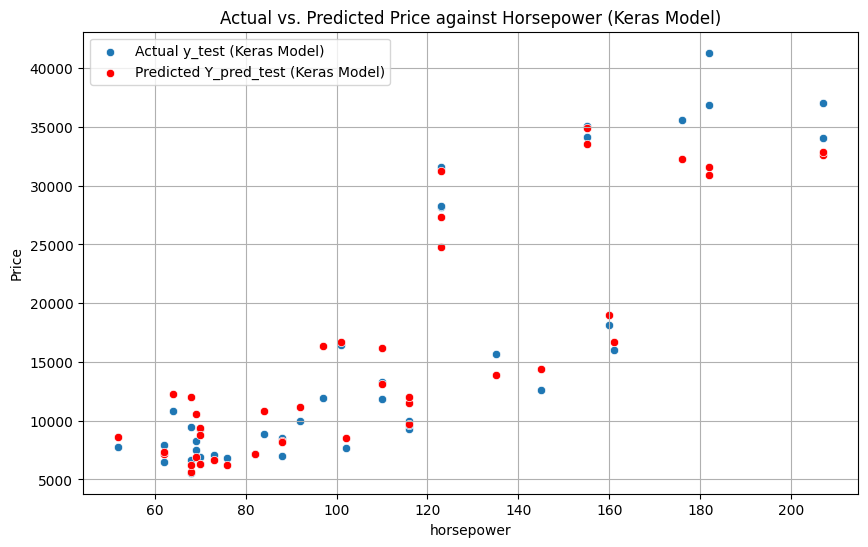

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_keras["horsepower"], y=y_test_original, label='Actual y_test (Keras Model)')
sns.scatterplot(x=X_test_keras["horsepower"], y=y_pred_keras, color="red", label='Predicted Y_pred_test (Keras Model)')
plt.title('Actual vs. Predicted Price against Horsepower (Keras Model)')
plt.xlabel('horsepower')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error


In [ ]:
pip install gradio


In [11]:

import gradio as gr
import joblib
import pandas as pd
import numpy as np


try:

    model = best_model_revisited
except NameError:
    print("Keras model 'best_model_revisited' not found. Ensure previous cells are run.")
    model = None


DATASET_DEFAULTS = {
    "highway-mpg": 30.0,
    "city-mpg": 25.0,
    "peak-rpm": 5200.0,
    "horsepower": 104.0,
    "compression-ratio": 10.0,
    "stroke": 3.2,
    "bore": 3.3,
    "engine-size": 120.0,
    "curb-weight": 2500.0,
    "height": 54.0,
    "width": 66.0,
    "length": 170.0,
    "wheel-base": 98.0,
    "normalized-losses": 122.0,

    "fuel-system": "mpfi",
    "engine-type": "ohc",
    "num-of-cylinders": "four",
    "num-of-doors": "four",
    "engine-location": "front",
    "drive-wheels": "fwd",
    "body-style": "sedan",
    "aspiration": "std",
    "fuel-type": "gas",
    "make": "toyota",
}

def predict_car_price(
    highway_mpg, unknown_highway_mpg,
    city_mpg, unknown_city_mpg,
    peak_rpm, unknown_peak_rpm,
    horsepower, unknown_horsepower,
    compression_ratio, unknown_compression_ratio,
    stroke, unknown_stroke,
    bore, unknown_bore,
    engine_size, unknown_engine_size,
    length, unknown_length,
    wheel_base, unknown_wheel_base,
    normalized_losses, unknown_normalized_losses,
    curb_weight, unknown_curb_weight,
    height, unknown_height,
    width, unknown_width,

    fuel_system,
    fuel_type,
    aspiration,
    make,
    body_style,
    drive_wheels,
    engine_location,
    num_of_doors,
    num_of_cylinders,
    engine_type
):

    final_highway_mpg = DATASET_DEFAULTS["highway-mpg"] if unknown_highway_mpg else highway_mpg
    final_city_mpg = DATASET_DEFAULTS["city-mpg"] if unknown_city_mpg else city_mpg
    final_peak_rpm = DATASET_DEFAULTS["peak-rpm"] if unknown_peak_rpm else peak_rpm
    final_horsepower = DATASET_DEFAULTS["horsepower"] if unknown_horsepower else horsepower
    final_compression_ratio = DATASET_DEFAULTS["compression-ratio"] if unknown_compression_ratio else compression_ratio
    final_stroke = DATASET_DEFAULTS["stroke"] if unknown_stroke else stroke
    final_bore = DATASET_DEFAULTS["bore"] if unknown_bore else bore
    final_engine_size = DATASET_DEFAULTS["engine-size"] if unknown_engine_size else engine_size
    final_length = DATASET_DEFAULTS["length"] if unknown_length else length
    final_wheel_base = DATASET_DEFAULTS["wheel-base"] if unknown_wheel_base else wheel_base
    final_normalized_losses = DATASET_DEFAULTS["normalized-losses"] if unknown_normalized_losses else normalized_losses
    final_curb_weight = DATASET_DEFAULTS["curb-weight"] if unknown_curb_weight else curb_weight
    final_height = DATASET_DEFAULTS["height"] if unknown_height else height
    final_width = DATASET_DEFAULTS["width"] if unknown_width else width


    final_fuel_system = DATASET_DEFAULTS["fuel-system"] if fuel_system == "Don't Know" else fuel_system
    final_fuel_type = DATASET_DEFAULTS["fuel-type"] if fuel_type == "Don't Know" else fuel_type
    final_aspiration = DATASET_DEFAULTS["aspiration"] if aspiration == "Don't Know" else aspiration
    final_make = DATASET_DEFAULTS["make"] if make == "Don't Know" else make
    final_body_style = DATASET_DEFAULTS["body-style"] if body_style == "Don't Know" else body_style
    final_drive_wheels = DATASET_DEFAULTS["drive-wheels"] if drive_wheels == "Don't Know" else drive_wheels
    final_engine_location = DATASET_DEFAULTS["engine-location"] if engine_location == "Don't Know" else engine_location
    final_num_of_doors = DATASET_DEFAULTS["num-of-doors"] if num_of_doors == "Don't Know" else num_of_doors
    final_num_of_cylinders = DATASET_DEFAULTS["num-of-cylinders"] if num_of_cylinders == "Don't Know" else num_of_cylinders
    final_engine_type = DATASET_DEFAULTS["engine-type"] if engine_type == "Don't Know" else engine_type


    input_data = {

        "highway-mpg": [final_highway_mpg],
        "city-mpg": [final_city_mpg],
        "peak-rpm": [final_peak_rpm],
        "horsepower": [final_horsepower],
        "compression-ratio": [final_compression_ratio],
        "stroke": [final_stroke],
        "bore": [final_bore],
        "engine-size": [final_engine_size],
        "curb-weight": [final_curb_weight],
        "height": [final_height],
        "width": [final_width],
        "length": [final_length],
        "wheel-base": [final_wheel_base],
        "normalized-losses": [final_normalized_losses],

        # Categorical Features
        "fuel-system": [final_fuel_system],
        "fuel-type": [final_fuel_type],
        "aspiration": [final_aspiration],
        "make": [final_make],
        "body-style": [final_body_style],
        "drive-wheels": [final_drive_wheels],
        "engine-location": [final_engine_location],
        "num-of-doors": [final_num_of_doors],
        "num-of-cylinders": [final_num_of_cylinders],
        "engine-type": [final_engine_type],
    }

    df_input = pd.DataFrame(input_data)


    if 'X_processed' not in globals() or 'scaler_keras' not in globals() or 'y_scaler_keras' not in globals():
        return "Error: Preprocessing components (X_processed, scaler_keras, y_scaler_keras) not found. Please run all preceding data preprocessing and scaling cells."


    for col in ['horsepower', 'curb-weight', 'engine-size']:
        if col in df_input.columns:
            df_input[col] = pd.to_numeric(df_input[col], errors='coerce')


    for col, default_val in DATASET_DEFAULTS.items():
        if col in df_input.columns and df_input[col].isnull().any():
            df_input[col] = df_input[col].fillna(default_val)


    df_input_processed = pd.get_dummies(df_input, drop_first=True)


    if 'horsepower' in df_input_processed.columns and 'curb-weight' in df_input_processed.columns:
        df_input_processed['horsepower_to_weight_ratio'] = df_input_processed['horsepower'] / df_input_processed['curb-weight']

    if 'engine-size' in df_input_processed.columns:
        df_input_processed['engine_size_sq'] = df_input_processed['engine-size'] ** 2

    if 'horsepower' in df_input_processed.columns:
        df_input_processed['horsepower_sq'] = df_input_processed['horsepower'] ** 2


    missing_cols = set(X_processed.columns) - set(df_input_processed.columns)
    for c in missing_cols:
        df_input_processed[c] = 0
    df_input_processed = df_input_processed[X_processed.columns]


    scaled_input = scaler_keras.transform(df_input_processed)

    if model:
        try:
            prediction_scaled = model.predict(scaled_input)

            prediction = y_scaler_keras.inverse_transform(prediction_scaled).flatten()[0]
            return f"${prediction:,.2f}"
        except Exception as err:
            return f"Error during model prediction: {str(err)}"
    else:

        base = (final_horsepower * 150) + (final_engine_size * 40)
        return f"${max(5000, base):,.2f} (Demo Mode - Model Not Loaded)"

with gr.Blocks(title="🚗 Automobile Price Evaluator") as demo:
    gr.Markdown("# 🚗 Automobile Price Valuation Estimator")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### ⚙️ Performance & Engine Specs")
            engine_size = gr.Slider(minimum=60, maximum=330, value=120, step=1, label="Engine Size (cid)")
            unknown_engine_size = gr.Checkbox(label=" Don't know Engine Size (Uses average)", value=False)

            horsepower = gr.Slider(minimum=40, maximum=800, value=100, step=1, label="Horsepower")
            unknown_horsepower = gr.Checkbox(label=" Don't know Horsepower (Uses average)", value=False)

            peak_rpm = gr.Slider(minimum=4000, maximum=7000, value=5200, step=50, label="Peak RPM")
            unknown_peak_rpm = gr.Checkbox(label=" Don't know Peak RPM (Uses average)", value=False)

            compression_ratio = gr.Number(value=10.0, label="Compression Ratio")
            unknown_compression_ratio = gr.Checkbox(label=" Don't know Compression Ratio (Uses average)", value=False)

            bore = gr.Number(value=3.3, label="Bore")
            unknown_bore = gr.Checkbox(label=" Don't know Bore (Uses average)", value=False)

            stroke = gr.Number(value=3.2, label="Stroke")
            unknown_stroke = gr.Checkbox(label=" Don't know Stroke (Uses average)", value=False)

            curb_weight = gr.Slider(minimum=1400, maximum=4100, value=2500, step=1, label="Curb Weight (lbs)") # New Feature
            unknown_curb_weight = gr.Checkbox(label=" Don't know Curb Weight (Uses average)", value=False)

            fuel_system = gr.Dropdown(
                choices=["Don't Know", "1bbl", "2bbl", "4bbl", "idi", "mfi", "mpfi", "spdi", "spfi"],
                value="mpfi",
                label="Fuel System"
            )
            num_of_cylinders = gr.Dropdown(
                choices=["Don't Know", "two", "three", "four", "five", "six", "eight", "twelve"],
                value="four",
                label="Number of Cylinders"
            )
            engine_type = gr.Dropdown(
                choices=["Don't Know", "dohc", "dohcv", "l", "ohc", "ohcf", "ohcv", "rotor"],
                value="ohc",
                label="Engine Type"
            )
            fuel_type = gr.Radio(choices=["Don't Know", "gas", "diesel"], value="gas", label="Fuel Type")
            aspiration = gr.Radio(choices=["Don't Know", "std", "turbo"], value="std", label="Aspiration")
            city_mpg = gr.Slider(minimum=10, maximum=50, value=25, step=1, label="City MPG")
            unknown_city_mpg = gr.Checkbox(label=" Don't know City MPG (Uses average)", value=False)
            highway_mpg = gr.Slider(minimum=15, maximum=60, value=30, step=1, label="Highway MPG")
            unknown_highway_mpg = gr.Checkbox(label=" Don't know Highway MPG (Uses average)", value=False)

        with gr.Column():
            gr.Markdown("### 📐 Physical Dimensions & Logistics")
            make = gr.Dropdown(choices=["Don't Know", 'alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury', 'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], value="toyota", label="Manufacturer (Make)")
            body_style = gr.Dropdown(choices=["Don't Know", "sedan", "hatchback", "convertible", "hardtop", "wagon"], value="sedan", label="Body Style")
            drive_wheels = gr.Radio(choices=["Don't Know", "fwd", "rwd", "4wd"], value="fwd", label="Drive Wheels")
            engine_location = gr.Radio(choices=["Don't Know", "front", "rear"], value="front", label="Engine Location")
            num_of_doors = gr.Radio(choices=["Don't Know", "two", "four"], value="four", label="Number of Doors")
            length = gr.Number(value=170.0, label="Length (inches)")
            unknown_length = gr.Checkbox(label=" Don't know Length (Uses average)", value=False)
            width = gr.Number(value=66.0, label="Width (inches)") # New Feature
            unknown_width = gr.Checkbox(label=" Don't know Width (Uses average)", value=False)
            height = gr.Number(value=54.0, label="Height (inches)") # New Feature
            unknown_height = gr.Checkbox(label=" Don't know Height (Uses average)", value=False)
            wheel_base = gr.Number(value=98.0, label="Wheel Base (inches)")
            unknown_wheel_base = gr.Checkbox(label=" Don't know Wheel Base (Uses average)", value=False)
            normalized_losses = gr.Number(value=122, precision=0, label="Normalized Losses")
            unknown_normalized_losses = gr.Checkbox(label=" Don't know Normalized Losses (Uses average)", value=False)

            gr.Markdown("--- Sizing of Car --- ")
            gr.Markdown("--- Other Specs --- ")
            predict_btn = gr.Button("Determine Car Price", variant="primary")
            output_price = gr.Textbox(label="Estimated Market Value")


    inputs_list = [
        highway_mpg, unknown_highway_mpg,
        city_mpg, unknown_city_mpg,
        peak_rpm, unknown_peak_rpm,
        horsepower, unknown_horsepower,
        compression_ratio, unknown_compression_ratio,
        stroke, unknown_stroke,
        bore, unknown_bore,
        engine_size, unknown_engine_size,
        length, unknown_length,
        wheel_base, unknown_wheel_base,
        normalized_losses, unknown_normalized_losses,
        curb_weight, unknown_curb_weight,
        height, unknown_height,
        width, unknown_width,

        fuel_system,
        fuel_type,
        aspiration,
        make,
        body_style,
        drive_wheels,
        engine_location,
        num_of_doors,
        num_of_cylinders,
        engine_type
    ]

    predict_btn.click(fn=predict_car_price, inputs=inputs_list, outputs=output_price)

if __name__ == "__main__":
    demo.launch()

Keras model 'best_model_revisited' not found. Ensure previous cells are run.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://16e1233393187c6712.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
X_train.columns

Index(['highway-mpg', 'city-mpg', 'peak-rpm', 'horsepower',
       'compression-ratio', 'stroke', 'bore', 'engine-size',
       'num-of-cylinders', 'curb-weight', 'height', 'width', 'length',
       'wheel-base', 'num-of-doors', 'normalized-losses', 'fuel-system_2bbl',
       'fuel-system_4bbl', 'fuel-system_idi', 'fuel-system_mfi',
       'fuel-system_mpfi', 'fuel-system_spdi', 'fuel-system_spfi',
       'engine-type_dohcv', 'engine-type_l', 'engine-type_ohc',
       'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor',
       'engine-location_rear', 'drive-wheels_fwd', 'drive-wheels_rwd',
       'body-style_hardtop', 'body-style_hatchback', 'body-style_sedan',
       'body-style_wagon', 'aspiration_turbo', 'fuel-type_gas', 'make_audi',
       'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu',
       'make_jaguar', 'make_mazda', 'make_mercedes-benz', 'make_mercury',
       'make_mitsubishi', 'make_nissan', 'make_peugot', 'make_plymouth',
       'make_porsch